# Stage 4: Regime Stability and Stress Testing

This stage freezes the models fit on the structural emergent world and tests how they behave when the economy moves. It runs a benign and a severe forward scenario with the same simulated borrowers in each (true common random numbers), a fixed composition variant, and real out of sample historical episodes. Episodes are scored only on confirmation block rows, so every reported episode is genuinely out of sample; an episode inside the training window (the 2008 crisis) is reported as excluded rather than scored in sample.

The heavy cells are checkpointed: with `REGENERATE = False` they reload the saved result files and the notebook opens in a few seconds; set `REGENERATE = True` to rerun the real experiment from scratch. This notebook does not import them: it needs only `credit_dgp.py` and `pipeline_utils.py`.

### 4.0 Setup and helpers

Load the same preprocessing recipe and the tuned hyperparameters from Stage 3, and define the small set of helpers (term builder, panel preparation, model fitting, and a scorer) that this stage needs.

In [ ]:
import os, sys, json, time, warnings, gc
import numpy as np, pandas as pd
# Make sure the project folder is importable so the simulator and helpers load from anywhere.
sys.path.insert(0, os.getcwd())
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score
from pygam import LogisticGAM, s, l, te
from interpret.glassbox import ExplainableBoostingClassifier
warnings.filterwarnings('ignore')
import credit_dgp as dgp
from pipeline_utils import (apply_preprocessing, make_logreg_fn, make_gam_fn, make_ebm_fn,
    make_emergent_truth_fn, time_blocked_loan_disjoint_split, load_json, save_json,
    expected_calibration_error, single_feature_pds, friedman_h2_and_bilinear)

OUT = 'outputs'
# False reuses saved stress results, True refits and recomputes (a few minutes).
REGENERATE = False
def cached(path): return (not REGENERATE) and os.path.exists(path)
def log(*a): print(f"[{time.strftime('%H:%M:%S')}]", *a, flush=True)
# Audit trail for the GAM tensor-interaction basis (same purpose as Stage 3): fit_models records whether
# each GAM fit used the intended tensor basis or fell back to additive-only, so the specification is
# never silent.
GAM_FALLBACK_LOG = []

# The preprocessing recipe, public ground truth, and the hyperparameters Stage 3 selected.
meta = load_json(f'{OUT}/preprocessing_meta.json'); gt = load_json('ground_truth_params.json')
TUNED = load_json(f'{OUT}/model_tuning.json')
BASE = meta['base_features']; IX = [p['col'] for p in meta['candidate_pairs']]; reg = meta['candidate_pairs']
col_ix = {c: i for i, c in enumerate(BASE)}
# The distinct micro and macro axes, used as the background features for the interaction ruler.
feats = sorted({p['micro'] for p in reg} | {p['macro'] for p in reg})
# Scale for the frozen fit and the number of paired stress seeds.
N_ORIG = 600; CRN_SEEDS = [1, 2, 3, 4, 5]; DEV_SUB = 90000
N_BG = 130            # background rows the interaction ruler averages over (matches Stage 3)
FLOOR_FRAC = 0.01     # H squared denominator floor stabiliser (matches Stage 3)

def build_terms(nsp):
    # Same GAM formula builder as Stage 3: smooth main effects, linear terms, and 35 tensor interactions.
    t = None
    for c in meta['micro_z_smooth'] + meta['macro_z_smooth']:
        tt = s(col_ix[c], n_splines=5); t = tt if t is None else t + tt
    for c in BASE:
        if c not in meta['micro_z_smooth'] and c not in meta['macro_z_smooth']: t = t + l(col_ix[c])
    for p in reg:
        if p['micro'] == 'emp_self_employed':
            tt = te(col_ix[p['micro']], col_ix[p['macro']], n_splines=[2, nsp], spline_order=[1, 3])
        else:
            tt = te(col_ix[p['micro']], col_ix[p['macro']], n_splines=[nsp, nsp])
        t = t + tt
    return t
class _P:
    def __init__(self, pr): self.params = pr
def prep(pan):
    # Filter to observed outcomes, preprocess, and attach the train and test block label.
    mdl = pan[pan['default_next_quarter'].notna()].copy(); mdl['default_next_quarter'] = mdl['default_next_quarter'].astype(int)
    X = apply_preprocessing(mdl, meta); X['part'] = time_blocked_loan_disjoint_split(X, meta['split']['dev_end'], meta['split']['val_end'])
    return X[X['part'].notna()].copy()
def fit_models(dev, tag=None):
    # Fit all three models with the tuned settings on a fixed size development sample.
    d = dev if len(dev) <= DEV_SUB else dev.sample(DEV_SUB, random_state=7); y = d['default_next_quarter'].values; Xb = d[BASE].astype(float).values
    lr = LogisticRegression(penalty='l2', C=TUNED['LR']['C'], max_iter=3000, solver='lbfgs').fit(d[BASE + IX].astype(float).values, y)
    lrp = pd.Series({'const': float(lr.intercept_[0]), **dict(zip(BASE + IX, lr.coef_[0]))})
    gam_fell_back = False
    try: gam = LogisticGAM(build_terms(TUNED['GAM']['n_splines']), max_iter=100, lam=TUNED['GAM']['lam']).fit(Xb, y)
    except Exception as _e:
        gam_fell_back = True; log(f'   GAM tensor basis FELL BACK to additive-only (tag={tag}):', _e)
        lin = None
        for i in range(len(BASE)): lin = l(i) if lin is None else lin + l(i)
        gam = LogisticGAM(lin, max_iter=100, lam=1.0).fit(Xb, y)
    GAM_FALLBACK_LOG.append({'tag': tag, 'fell_back': bool(gam_fell_back),
                             'basis': 'additive_only' if gam_fell_back else 'tensor_interactions'})
    ebm = ExplainableBoostingClassifier(interactions=[(col_ix[p['micro']], col_ix[p['macro']]) for p in reg],
                                        outer_bags=2, max_rounds=2000, learning_rate=TUNED['EBM']['learning_rate'],
                                        random_state=42, n_jobs=1).fit(Xb, y)
    return {'Logistic': make_logreg_fn(_P(lrp), meta), 'GAM': make_gam_fn(gam, meta), 'EBM': make_ebm_fn(ebm, meta)}
def score(fns, X):
    # Score every model on a feature frame: AUC, Brier, calibration error, calibration slope, average
    # precision, mean predicted PD, realised default rate, and the predicted-minus-realised gap. The
    # calibration slope (logistic regression of the outcome on the predicted log-odds; 1.0 = calibrated
    # in the large) and average precision (PR-curve area) were added so the stress evidence carries the
    # stronger calibration/minority-class views requested in the critical evaluation.
    y = X['default_next_quarter'].values; out = {}
    for m, f in fns.items():
        lp = np.asarray(f(X)); p = expit(lp)
        both = 1 < int(y.sum()) < len(y)
        if both:
            cs = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000).fit(lp.reshape(-1, 1), y)
            cal_slope = float(cs.coef_[0, 0]); ap = float(average_precision_score(y, p))
        else:
            cal_slope = float('nan'); ap = float('nan')
        out[m] = {'auc': float(roc_auc_score(y, p)) if both else float('nan'),
                  'brier': float(brier_score_loss(y, p)), 'ece': float(expected_calibration_error(y, p)),
                  'cal_slope': cal_slope, 'avg_precision': ap,
                  'mean_pd_%': float(p.mean() * 100), 'realised_%': float(y.mean() * 100), 'pd_gap_pp': float((p.mean() - y.mean()) * 100)}
    return out
def rulers(FNS, Xbg):
    # Apply the identical H squared and b hat ruler that Stage 3 uses, so a model's interaction
    # fingerprint under stress is measured on exactly the same scale as its in sample recovery.
    H2 = {m: {} for m in FNS}; BH = {m: {} for m in FNS}
    for m, f in FNS.items():
        base_pred = np.asarray(f(Xbg)); pv = float(np.var(base_pred - base_pred.mean()))
        pd1 = single_feature_pds(f, Xbg, feats)
        for p in reg:
            h, b = friedman_h2_and_bilinear(f, Xbg, p['micro'], p['macro'], pd1, pred_var=pv, floor_frac=FLOOR_FRAC)
            H2[m][p['col']] = float(h); BH[m][p['col']] = float(b)
    return H2, BH
print('Stage 4 setup ready. REGENERATE =', REGENERATE)

Stage 4 setup ready. REGENERATE = False


### 4.1 Forward scenarios and stress transport

Freeze the models on the structural emergent seed 1 world, then roll the same simulated borrowers through a benign and a severe sixteen quarter macro path. Origination conditions are pinned to a neutral reference so the borrower population is identical across the two scenarios, which isolates the pure effect of the macro path. The fixed composition test holds the exact same borrowers and only swaps the macro inputs. Historical episodes are scored on confirmation rows only so they are genuinely out of sample.

In [36]:
FWD_PATH = f'{OUT}/stress_forward.json'; FIX_PATH = f'{OUT}/stress_fixed_composition.json'; EPI_PATH = f'{OUT}/stress_episodes.json'
TRAJ_PATH = 'figures/trajectory_data.json'; SCEN_PATH = 'figures/scenario_data.json'
EXPL_PATH = f'{OUT}/explanation_stability.json'
# Skip the whole compute only when every saved output is present, including the two small plot data files
# the figures need. If any is missing we refit and recompute everything, which keeps the cell self sufficient.
if cached(FWD_PATH) and cached(FIX_PATH) and cached(EPI_PATH) and os.path.exists(TRAJ_PATH) and os.path.exists(SCEN_PATH) and cached(EXPL_PATH):
    # Reuse the saved stress results and plot data.
    print('loaded saved stress results and plot data (forward, fixed composition, episodes, trajectory).')
else:
    # Fit the frozen models once on the structural emergent seed 1 development data.
    log('fitting frozen structural emergent seed 1 models ...')
    ref_pan = dgp.generate_panel(seed=1, n_orig_per_quarter=N_ORIG, mode='emergent', use_vasicek=False, paired_seed=777)
    refX = prep(ref_pan); FROZEN = fit_models(refX[refX['part'] == 'dev'], tag='frozen_emergent_seed1')
    log('frozen models ready.')

    # Helper to build a raw sixteen quarter macro frame from the eight series.
    def raw_frame(u, c, r, g, w, dsr, cg, sv):
        q = pd.period_range('2026Q1', periods=16, freq='Q')
        return pd.DataFrame({'quarter': q, 'unemployment': u, 'cpi_inflation': c, 'bank_rate': r, 'gdp_growth': g,
                             'wage_growth': w, 'dsr': dsr, 'credit_growth': cg, 'saving_ratio': sv})
    # Benign baseline path: unemployment easing to 4 percent, inflation to target, rate easing.
    BASE_SCN = raw_frame([4.4,4.4,4.3,4.3,4.2,4.2,4.2,4.1,4.1,4.1,4.0,4.0,4.0,4.0,4.0,4.0],
        [2.5,2.3,2.2,2.1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0],
        [4.50,4.25,4.00,3.75,3.75,3.50,3.50,3.25,3.25,3.25,3.25,3.25,3.25,3.25,3.25,3.25],
        [0.4]*16, [3.5]*16, [8.6]*16, [5.0]*16, [10.0]*16)
    # Severe path: unemployment to 8.5 percent, an inflation spike, rate to 6 percent, a GDP contraction.
    SEV_SCN = raw_frame([4.6,5.2,5.9,6.6,7.2,7.7,8.1,8.4,8.5,8.5,8.4,8.3,8.1,7.8,7.5,7.2],
        [9.0,12.0,15.0,17.0,16.0,14.0,11.0,9.0,7.5,6.5,5.5,5.0,4.5,4.0,3.5,3.0],
        [5.00,5.50,6.00,6.00,6.00,6.00,6.00,5.75,5.50,5.25,5.00,4.75,4.50,4.25,4.00,4.00],
        [-0.8,-1.6,-2.0,-1.5,-1.0,-0.4,0.1,0.4,0.5,0.6,0.6,0.6,0.5,0.5,0.5,0.5],
        [4.5]*16, [10.0]*16, [-2.0]*16, [13.0]*16)
    # Turn the raw paths into the standardised macro frames the simulator consumes.
    BASE_F = dgp.build_macro_frame(BASE_SCN, dgp.HIST_STATS); SEV_F = dgp.build_macro_frame(SEV_SCN, dgp.HIST_STATS)
    # Neutral origination macro so the borrower population is identical across the two scenarios.
    CRN_ORIG = {'bank_rate': dgp._MEAN_BANK_RATE, 'zU': 0.0, 'zDSR': 0.0, 'zCredit': 0.0}

    # Roll the same borrowers through each scenario for five paired seeds and average.
    log('forward scenarios (true CRN, dynamic composition), 5 seeds ...')
    dyn = {'baseline': {m: [] for m in FROZEN}, 'severe': {m: [] for m in FROZEN}}; crn_pairs = {m: [] for m in FROZEN}
    for sd in CRN_SEEDS:
        pb = dgp.generate_panel(BASE_F, seed=sd, n_orig_per_quarter=N_ORIG, mode='emergent', use_vasicek=False, paired_seed=900+sd, crn_orig=CRN_ORIG)
        ps = dgp.generate_panel(SEV_F, seed=sd, n_orig_per_quarter=N_ORIG, mode='emergent', use_vasicek=False, paired_seed=900+sd, crn_orig=CRN_ORIG)
        Xb = prep(pb); Xs = prep(ps); sb = score(FROZEN, Xb); ss = score(FROZEN, Xs)
        for m in FROZEN:
            dyn['baseline'][m].append(sb[m]); dyn['severe'][m].append(ss[m]); crn_pairs[m].append(ss[m]['mean_pd_%'] - sb[m]['mean_pd_%'])
        log(f'  CRN seed {sd} done'); del pb, ps, Xb, Xs; gc.collect()
    def agg(lst, k): return round(float(np.mean([x[k] for x in lst])), 3)
    # Forward stress summary. Both the benign baseline AND the severe scenario now carry their realised
    # default rate, Brier score, ECE, calibration slope and predicted-minus-realised gap, so baseline
    # calibration can be judged directly (previously only the severe gap was retained). The five raw
    # per-seed severe-minus-baseline PD deltas are also saved (crn_delta_pp_raw), so the Table 4.6 test
    # can be a proper sample t-test rather than a reconstruction from rounded summaries.
    stress_forward = {m: {
        'baseline_auc': agg(dyn['baseline'][m], 'auc'), 'severe_auc': agg(dyn['severe'][m], 'auc'),
        'baseline_pd_%': agg(dyn['baseline'][m], 'mean_pd_%'), 'severe_pd_%': agg(dyn['severe'][m], 'mean_pd_%'),
        'baseline_realised_%': agg(dyn['baseline'][m], 'realised_%'), 'severe_realised_%': agg(dyn['severe'][m], 'realised_%'),
        'baseline_pd_gap_pp': agg(dyn['baseline'][m], 'pd_gap_pp'), 'severe_pd_gap_pp': agg(dyn['severe'][m], 'pd_gap_pp'),
        'baseline_brier': agg(dyn['baseline'][m], 'brier'), 'severe_brier': agg(dyn['severe'][m], 'brier'),
        'baseline_ece': agg(dyn['baseline'][m], 'ece'), 'severe_ece': agg(dyn['severe'][m], 'ece'),
        'baseline_cal_slope': agg(dyn['baseline'][m], 'cal_slope'), 'severe_cal_slope': agg(dyn['severe'][m], 'cal_slope'),
        'crn_delta_pp_mean': round(float(np.mean(crn_pairs[m])), 3), 'crn_delta_pp_sd': round(float(np.std(crn_pairs[m])), 3),
        'crn_delta_pp_raw': [round(float(v), 4) for v in crn_pairs[m]]} for m in FROZEN}
    save_json(stress_forward, FWD_PATH)

    # Fixed composition: the same development borrowers, macro columns overwritten with one representative
    # baseline quarter and one representative severe quarter, with no resimulation.
    log('fixed composition ...')
    def scen_end_row(F, q):
        r = F.iloc[q]; return {c: float(r[c]) for c in ['unemployment','cpi_inflation','bank_rate','gdp_growth','wage_growth','dsr','credit_growth','saving_ratio']}
    base_row = scen_end_row(BASE_F, 7); sev_row = scen_end_row(SEV_F, 3)
    raw_ref = ref_pan[ref_pan['default_next_quarter'].notna()].copy()
    raw_ref = raw_ref[raw_ref['origination_quarter'].astype('period[Q]') <= pd.Period(meta['split']['dev_end'], 'Q')]
    fixed = {}
    for label, row in [('baseline', base_row), ('severe', sev_row)]:
        rr = raw_ref.copy()
        for c, v in row.items(): rr[c] = v
        Xf = apply_preprocessing(rr, meta); Xf['default_next_quarter'] = rr['default_next_quarter'].astype(int).values
        sc = score(FROZEN, Xf); fixed[label] = {m: round(sc[m]['mean_pd_%'], 3) for m in FROZEN}
    stress_fixed = {m: {'fixed_baseline_pd_%': fixed['baseline'][m], 'fixed_severe_pd_%': fixed['severe'][m],
                        'fixed_delta_pp': round(fixed['severe'][m] - fixed['baseline'][m], 3)} for m in FROZEN}
    save_json(stress_fixed, FIX_PATH)

    # Historical episodes scored on confirmation rows only, so every reported episode is out of sample.
    log('historical episodes (out of sample rows only) ...')
    EPI = {'GFC_2008': ('2008Q3', '2010Q2'), 'COVID_2020': ('2020Q1', '2021Q2'), 'inflation_2022': ('2022Q1', '2023Q4')}
    conf_only = refX[refX['part'] == 'conf']
    epi = {}; epi_excluded = {}
    for name, (q0, q1) in EPI.items():
        sub = conf_only[(conf_only['observation_quarter'].astype(str) >= q0) & (conf_only['observation_quarter'].astype(str) <= q1)]
        # An episode with too few out of sample rows falls inside the training window and cannot be a fair
        # out of sample test, so it is recorded as excluded rather than scored.
        if len(sub) < 200 or sub['default_next_quarter'].sum() < 2:
            epi_excluded[name] = {'n_out_of_sample_rows': int(len(sub)),
                'reason': 'window falls inside the training block under the temporal split; no out of sample rows'}
            continue
        sc = score(FROZEN, sub); epi[name] = {m: {'auc': round(sc[m]['auc'], 3), 'pd_gap_pp': round(sc[m]['pd_gap_pp'], 2), 'n': int(len(sub))} for m in FROZEN}
    save_json({'out_of_sample_episodes': epi, 'excluded': epi_excluded,
               'note': 'Episodes scored on confirmation rows only (origination and observation after 2019Q4), so all reported episodes are out of sample.'}, EPI_PATH)

    # Plot data for the figures. Reusing the frozen models, roll the same borrowers through each scenario
    # and record BOTH the mean predicted PD and the REALISED default rate in every scenario quarter, so
    # the trajectory figure can show predicted-vs-actual over time, not predictions alone (previously only
    # the predicted trajectory was retained). Also save the raw scenario macro paths.
    os.makedirs('figures', exist_ok=True)
    def traj(F):
        # Simulate the scenario panel; return each model's predicted PD and the realised default rate,
        # both averaged by observation quarter and aligned to a shared, sorted quarter axis.
        pan = dgp.generate_panel(F, seed=1, n_orig_per_quarter=N_ORIG, mode='emergent', use_vasicek=False, paired_seed=901, crn_orig=CRN_ORIG)
        Xp = prep(pan); Xp['_q'] = Xp['observation_quarter'].astype(str)
        quarters = sorted(Xp['_q'].unique().tolist())
        out = {'quarters': quarters,
               'actual': (Xp.groupby('_q')['default_next_quarter'].mean() * 100).reindex(quarters).tolist()}
        for m, f in FROZEN.items():
            Xp['_pd'] = expit(np.asarray(f(Xp)))
            out[m] = (Xp.groupby('_q')['_pd'].mean() * 100).reindex(quarters).tolist()
        return out
    save_json({'baseline': traj(BASE_F), 'severe': traj(SEV_F)}, TRAJ_PATH)
    save_json({'unemployment': {'baseline': list(map(float, BASE_SCN['unemployment'])), 'severe': list(map(float, SEV_SCN['unemployment']))},
               'cpi': {'baseline': list(map(float, BASE_SCN['cpi_inflation'])), 'severe': list(map(float, SEV_SCN['cpi_inflation']))},
               'bank_rate': {'baseline': list(map(float, BASE_SCN['bank_rate'])), 'severe': list(map(float, SEV_SCN['bank_rate']))}}, SCEN_PATH)
    # Explanation (interaction) stability AND faithfulness under stress, averaged over the 5 CRN seeds so
    # both carry the same variance control as the forward stress transport above. For each seed we draw a
    # background per regime and measure every FROZEN model's interaction fingerprint (b hat per candidate
    # pair) with the Stage 3 ruler. STABILITY compares each stress regime to that SAME seed's benign
    # baseline (does the model tell the same story as the economy moves). FAITHFULNESS compares each
    # regime's fingerprint to the EMERGENT STRUCTURAL ORACLE evaluated on the same stressed background
    # (is the story economically correct under stress). The oracle is a deterministic function of the
    # features, so it defines the true interaction structure at any macro state, including the severe
    # out-of-support path; this is the severe-scenario structural oracle whose absence the critical
    # evaluation flagged, so the project can now test stressed correctness, not only stressed stability.
    log('explanation stability + faithfulness under stress (5 CRN seeds) ...')
    f_em = make_emergent_truth_fn(gt, meta)
    STRESS_REGIMES = ['severe', 'COVID_2020', 'inflation_2022']
    FAITH_REGIMES = ['baseline'] + STRESS_REGIMES
    EPI_WIN = {'COVID_2020': ('2020Q1', '2021Q2'), 'inflation_2022': ('2022Q1', '2023Q4')}
    # Per seed stability values (vs own baseline) and faithfulness values (vs oracle same regime).
    _ps_stab = {m: {rg: {'sign_preservation': [], 'rank_corr_spearman': [], 'mean_abs_db': [], 'rmse_db': []}
                    for rg in STRESS_REGIMES} for m in FROZEN}
    _ps_faith = {m: {rg: {'sign_agree': [], 'rank_corr_spearman': [], 'rmse': [], 'mean_abs_diff': []}
                     for rg in FAITH_REGIMES} for m in FROZEN}
    _fp_acc = {m: {rg: [] for rg in FAITH_REGIMES} for m in list(FROZEN) + ['Oracle']}
    for _sd in CRN_SEEDS:
        # Benign baseline and severe forward panels for this seed (same borrowers via CRN), plus a
        # structural panel whose confirmation rows supply the real COVID and inflation episode backgrounds.
        _pb = dgp.generate_panel(BASE_F, seed=_sd, n_orig_per_quarter=N_ORIG, mode='emergent', use_vasicek=False, paired_seed=900+_sd, crn_orig=CRN_ORIG)
        _pv = dgp.generate_panel(SEV_F, seed=_sd, n_orig_per_quarter=N_ORIG, mode='emergent', use_vasicek=False, paired_seed=900+_sd, crn_orig=CRN_ORIG)
        _pe = dgp.generate_panel(seed=_sd, n_orig_per_quarter=N_ORIG, mode='emergent', use_vasicek=False, paired_seed=777)
        _Xb = prep(_pb); _Xv = prep(_pv); _Xe = prep(_pe); _confe = _Xe[_Xe['part'] == 'conf']
        _bg = {'baseline': _Xb.sample(min(N_BG, len(_Xb)), random_state=100).reset_index(drop=True),
               'severe': _Xv.sample(min(N_BG, len(_Xv)), random_state=100).reset_index(drop=True)}
        for _nm, (_q0, _q1) in EPI_WIN.items():
            _sub = _confe[(_confe['observation_quarter'].astype(str) >= _q0) & (_confe['observation_quarter'].astype(str) <= _q1)]
            if len(_sub) >= N_BG:
                _bg[_nm] = _sub.sample(N_BG, random_state=100).reset_index(drop=True)
        # Fingerprint (b hat per pair) for every frozen model AND the emergent oracle, in every regime.
        _fp = {m: {} for m in list(FROZEN) + ['Oracle']}
        for _rg, _Xbg in _bg.items():
            _, _BH = rulers({**FROZEN, 'Oracle': f_em}, _Xbg)
            for m in list(FROZEN) + ['Oracle']:
                _fp[m][_rg] = np.array([_BH[m][p['col']] for p in reg])
                _fp_acc[m][_rg].append(_fp[m][_rg])
        # STABILITY: each stress regime versus THIS seed's baseline fingerprint (model vs its own baseline).
        for m in FROZEN:
            _refb = _fp[m]['baseline']; _aref = np.abs(_refb); _mask = _aref >= np.quantile(_aref, 0.5)
            for _rg in STRESS_REGIMES:
                if _rg not in _fp[m]: continue
                _curb = _fp[m][_rg]; _db = _curb - _refb
                _sp = float(np.mean(np.sign(_curb[_mask]) == np.sign(_refb[_mask]))) if _mask.any() else float('nan')
                _rc = float(pd.Series(_curb).corr(pd.Series(_refb), method='spearman')) if _curb.std() > 0 and _refb.std() > 0 else float('nan')
                _ps_stab[m][_rg]['sign_preservation'].append(_sp)
                _ps_stab[m][_rg]['rank_corr_spearman'].append(_rc)
                _ps_stab[m][_rg]['mean_abs_db'].append(float(np.mean(np.abs(_db))))
                _ps_stab[m][_rg]['rmse_db'].append(float(np.sqrt(np.mean(_db ** 2))))
        # FAITHFULNESS: each regime's fingerprint versus the ORACLE fingerprint on the SAME regime
        # background (model vs the true stressed interaction structure). Sign agreement is scored on the
        # pairs where the oracle interaction is clearly non zero (|b| >= 0.05), matching Stage 3.
        for m in FROZEN:
            for _rg in FAITH_REGIMES:
                if _rg not in _fp[m] or _rg not in _fp['Oracle']: continue
                _mv = _fp[m][_rg]; _ov = _fp['Oracle'][_rg]; _om = np.abs(_ov) >= 0.05
                _fs = float(np.mean(np.sign(_mv[_om]) == np.sign(_ov[_om]))) if _om.any() else float('nan')
                _fc = float(pd.Series(_mv).corr(pd.Series(_ov), method='spearman')) if _mv.std() > 0 and _ov.std() > 0 else float('nan')
                _ps_faith[m][_rg]['sign_agree'].append(_fs)
                _ps_faith[m][_rg]['rank_corr_spearman'].append(_fc)
                _ps_faith[m][_rg]['rmse'].append(float(np.sqrt(np.mean((_mv - _ov) ** 2))))
                _ps_faith[m][_rg]['mean_abs_diff'].append(float(np.mean(np.abs(_mv - _ov))))
        log(f'  fingerprint seed {_sd} done')
        del _pb, _pv, _pe, _Xb, _Xv, _Xe; gc.collect()
    # Aggregate stability to mean (kept under the original metric key names so Stage 5 reads them
    # unchanged) plus SD.
    stab = {m: {} for m in FROZEN}
    for m in FROZEN:
        for _rg in STRESS_REGIMES:
            _v = _ps_stab[m][_rg]
            if not _v['sign_preservation']: continue
            stab[m][_rg] = {
                'sign_preservation': round(float(np.nanmean(_v['sign_preservation'])), 3),
                'sign_preservation_sd': round(float(np.nanstd(_v['sign_preservation'])), 3),
                'rank_corr_spearman': round(float(np.nanmean(_v['rank_corr_spearman'])), 3),
                'rank_corr_spearman_sd': round(float(np.nanstd(_v['rank_corr_spearman'])), 3),
                'mean_abs_db': round(float(np.mean(_v['mean_abs_db'])), 4),
                'mean_abs_db_sd': round(float(np.std(_v['mean_abs_db'])), 4),
                'rmse_db': round(float(np.mean(_v['rmse_db'])), 4)}
    # Aggregate faithfulness (model vs stressed structural oracle) to mean + SD per regime.
    faith = {m: {} for m in FROZEN}
    for m in FROZEN:
        for _rg in FAITH_REGIMES:
            _v = _ps_faith[m][_rg]
            if not _v['rmse']: continue
            faith[m][_rg] = {
                'sign_agree': round(float(np.nanmean(_v['sign_agree'])), 3),
                'sign_agree_sd': round(float(np.nanstd(_v['sign_agree'])), 3),
                'rank_corr_spearman': round(float(np.nanmean(_v['rank_corr_spearman'])), 3),
                'rank_corr_spearman_sd': round(float(np.nanstd(_v['rank_corr_spearman'])), 3),
                'rmse': round(float(np.mean(_v['rmse'])), 4),
                'rmse_sd': round(float(np.std(_v['rmse'])), 4),
                'mean_abs_diff': round(float(np.mean(_v['mean_abs_diff'])), 4)}
    # Mean fingerprint per regime over the seeds (frozen models AND the oracle), for the figures below.
    fp_b = {m: {_rg: np.mean(_fp_acc[m][_rg], axis=0).tolist() for _rg in _fp_acc[m] if _fp_acc[m][_rg]}
            for m in list(FROZEN) + ['Oracle']}
    save_json({'regimes': ['baseline'] + STRESS_REGIMES, 'reference': 'baseline', 'pairs': [p['col'] for p in reg],
               'n_seeds': len(CRN_SEEDS), 'bhat': fp_b, 'stability': stab, 'faithfulness': faith,
               'note': 'Frozen-model interaction fingerprint (b-hat per pair, Stage 3 ruler), averaged over 5 CRN seeds. STABILITY compares each stress regime to the SAME seed benign-baseline fingerprint (model vs its own baseline). FAITHFULNESS compares each regime to the emergent structural ORACLE evaluated on the same stressed background (model vs true stressed interaction structure); sign agreement is scored where the oracle |b|>=0.05. Baseline/severe are CRN forward panels; COVID/inflation are real out-of-sample episode windows.'}, EXPL_PATH)
    # GAM basis audit for this stage (see Stage 3): confirm every frozen/stress GAM fit used the tensor
    # interaction basis rather than silently falling back to additive-only.
    _fb = [r for r in GAM_FALLBACK_LOG if r['fell_back']]
    save_json({'n_gam_fits': len(GAM_FALLBACK_LOG), 'n_fell_back': len(_fb),
               'all_tensor_basis': len(GAM_FALLBACK_LOG) > 0 and len(_fb) == 0,
               'fallback_tags': [r['tag'] for r in _fb], 'detail': GAM_FALLBACK_LOG}, f'{OUT}/gam_fallback_stage4.json')
    del _ps_stab, _ps_faith, _fp_acc; gc.collect()
    log('STAGE 4 stress done; out of sample episodes', list(epi), 'excluded', list(epi_excluded))

loaded saved stress results and plot data (forward, fixed composition, episodes, trajectory).


### 4.2 Results

Forward scenario stress first (the severe gap is predicted minus realised, positive is over prediction and negative is under prediction), then the fixed versus dynamic composition comparison, then the out of sample episodes with the excluded window listed explicitly.

In [37]:
# Forward scenario stress summary.
fwd = load_json(f'{OUT}/stress_forward.json')
display(pd.DataFrame(fwd).T[['baseline_pd_%','severe_pd_%','severe_pd_gap_pp','baseline_auc','severe_auc','crn_delta_pp_mean','crn_delta_pp_sd']])

,baseline_pd_%,severe_pd_%,severe_pd_gap_pp,baseline_auc,severe_auc,crn_delta_pp_mean,crn_delta_pp_sd
Logistic,0.043,24.368,13.292,0.752,0.791,24.325,0.298
GAM,0.042,18.64,7.563,0.752,0.77,18.598,0.329
EBM,0.354,1.912,-9.165,0.757,0.829,1.558,0.019


In [38]:
# Is the severe-scenario shift in predicted PD a real, consistent effect across the 5 CRN-paired seeds,
# or noise from one unusual draw? The five raw per-seed severe-minus-baseline deltas are now saved
# (crn_delta_pp_raw), so this is a PROPER one-sample t-test on the raw values via scipy.stats.ttest_1samp
# (sample SD, ddof=1), not a reconstruction from rounded summaries. If an older results file without the
# raw values is loaded, it falls back to the summary-based formula and says so.
from scipy.stats import ttest_1samp, t as _tdist
fwd = load_json(f'{OUT}/stress_forward.json')
n = len(CRN_SEEDS)
rows = []
for m in fwd:
    raw = fwd[m].get('crn_delta_pp_raw')
    if raw is not None and len(raw) > 1:
        res = ttest_1samp(np.asarray(raw, float), 0.0)
        tstat, p = float(res.statistic), float(res.pvalue)
        mean, sd = float(np.mean(raw)), float(np.std(raw, ddof=1)); basis = 'raw seeds (sample SD)'
    else:
        mean, sd = fwd[m]['crn_delta_pp_mean'], fwd[m]['crn_delta_pp_sd']
        tstat = mean / (sd / np.sqrt(n)); p = 2 * _tdist.sf(abs(tstat), df=n - 1); basis = 'summary (population SD)'
    rows.append({'model': m, 'mean_delta_pp': round(mean, 3), 'sd_delta_pp': round(sd, 3),
                 't_stat': round(tstat, 2), 'df': n - 1, 'p_value': p, 'basis': basis})
print(f'One-sample t-test (H0: mean CRN-paired severe PD delta = 0), across {n} seeds:')
display(pd.DataFrame(rows).set_index('model'))

One-sample t-test (H0: mean CRN-paired severe PD delta = 0), across 5 seeds:


,mean_delta_pp,sd_delta_pp,t_stat,df,p_value,basis
model,,,,,,
Logistic,24.325,0.334,163.05,4,8.487020e-09,raw seeds (sample SD)
GAM,18.598,0.368,113.15,4,3.658509e-08,raw seeds (sample SD)
EBM,1.558,0.021,164.53,4,8.185669e-09,raw seeds (sample SD)


In [39]:
# Fixed composition versus dynamic composition severe delta. A large gap means borrower composition
# absorbs part of what a naive fixed book test would attribute to the macro shock.
fix = load_json(f'{OUT}/stress_fixed_composition.json'); fwd = load_json(f'{OUT}/stress_forward.json')
cmp = pd.DataFrame({'fixed_composition': {m: fix[m]['fixed_delta_pp'] for m in fix},
                    'dynamic_composition_CRN': {m: fwd[m]['crn_delta_pp_mean'] for m in fwd}})
cmp['ratio_fixed/dynamic'] = (cmp['fixed_composition'] / cmp['dynamic_composition_CRN']).round(2)
display(cmp)

,fixed_composition,dynamic_composition_CRN,ratio_fixed/dynamic
Logistic,64.664,24.325,2.66
GAM,36.566,18.598,1.97
EBM,1.963,1.558,1.26


In [40]:
# Out of sample historical episodes, and the window that had to be excluded.
epi = load_json(f'{OUT}/stress_episodes.json')
rows = []
for name, d in epi['out_of_sample_episodes'].items():
    for m, v in d.items(): rows.append({'episode': name, 'model': m, 'auc': v['auc'], 'pd_gap_pp': v['pd_gap_pp'], 'n': v['n']})
display(pd.DataFrame(rows).set_index(['episode', 'model']))
print('Excluded (no out of sample rows under the temporal split):', json.dumps(epi['excluded']))

auc  pd_gap_pp      n
episode        model                            
COVID_2020     Logistic  0.863       0.34  11548
               GAM       0.895       0.84  11548
               EBM       0.699       0.05  11548
inflation_2022 Logistic  0.761      -0.77  40382
               GAM       0.760      -1.35  40382
               EBM       0.837      -1.05  40382

Excluded (no out of sample rows under the temporal split): {"GFC_2008": {"n_out_of_sample_rows": 0, "reason": "window falls inside the training block under the temporal split; no out of sample rows"}}


### 4.3 Figures

Drawn inline from the plot data the cell above saved, not from pre made images.

**Figure 4.1: forward stress scenario macro paths.** The benign baseline and the severe path over sixteen quarters.

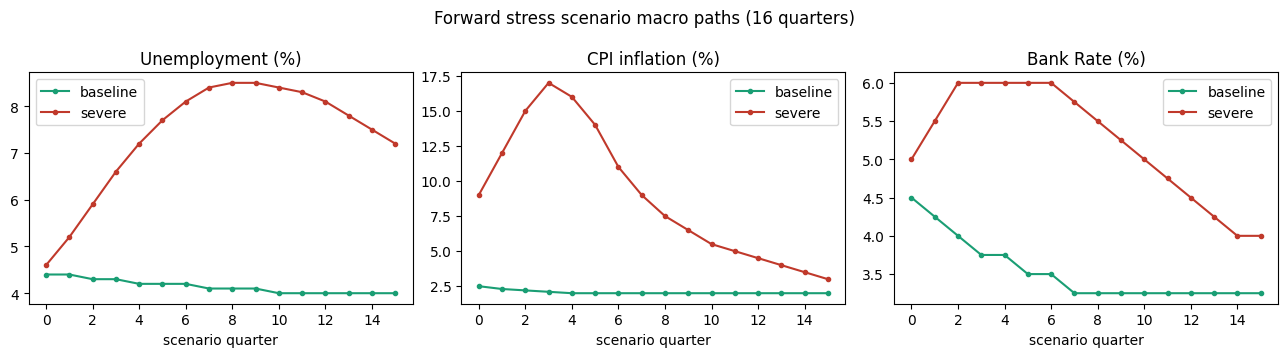

In [41]:
import matplotlib.pyplot as plt
# Draw the scenario macro paths live from the saved plot data.
sc = load_json('figures/scenario_data.json')
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for k, (key, lab) in enumerate([('unemployment', 'Unemployment (%)'), ('cpi', 'CPI inflation (%)'), ('bank_rate', 'Bank Rate (%)')]):
    ax[k].plot(sc[key]['baseline'], 'o-', color='#1a9e74', ms=3, label='baseline')
    ax[k].plot(sc[key]['severe'], 'o-', color='#c0392b', ms=3, label='severe')
    ax[k].set_title(lab); ax[k].set_xlabel('scenario quarter'); ax[k].legend()
fig.suptitle('Forward stress scenario macro paths (16 quarters)'); fig.tight_layout(); plt.show()

**Figure 4.2: predicted PD trajectory under stress.** The same borrowers rolled through each scenario. Under the baseline all three models stay low and close; under the severe scenario they diverge in opposite directions (Logistic and GAM climb steeply, EBM stays almost flat).

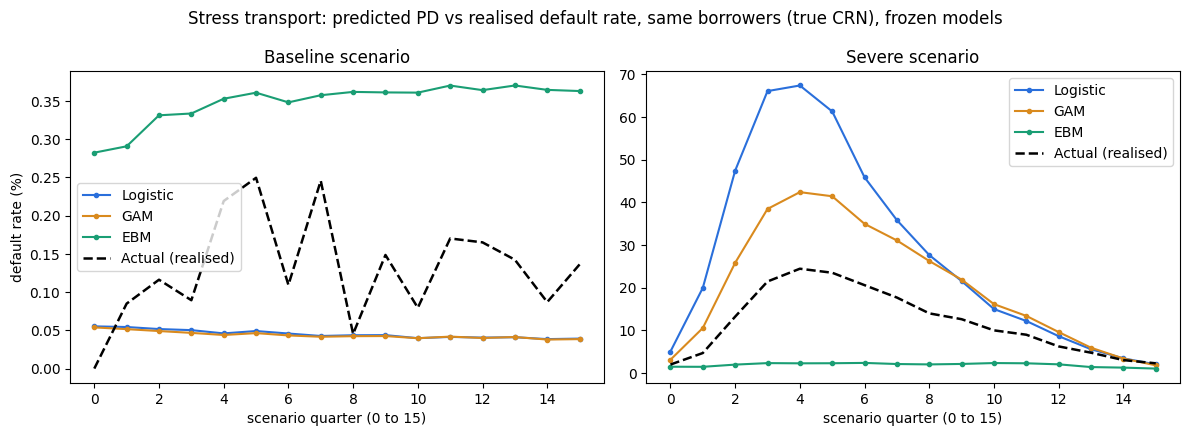

In [46]:
# Draw the stress trajectory live from the saved plot data. Both panels share one y-scale, so the
# true relative size of the severe-scenario swing versus the baseline is directly comparable (the
# trade-off is that baseline's own small quarter-to-quarter detail is harder to see at this scale).
# The black dashed line is the REALISED default rate per quarter (now saved alongside the predictions),
# so each model's predicted PD can be read against the truth it is trying to track, not in isolation.
td = load_json('figures/trajectory_data.json')
CLR = {'Logistic': '#2a6fdb', 'GAM': '#d98a1e', 'EBM': '#1a9e74'}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), sharey=False)
for k, scen in enumerate(['baseline', 'severe']):
    for m in ['Logistic', 'GAM', 'EBM']:
        ax[k].plot(range(len(td[scen][m])), td[scen][m], 'o-', color=CLR[m], ms=3, label=m)
    # Realised default rate (actual), if present in the saved data.
    if 'actual' in td[scen]:
        act = td[scen]['actual']
        ax[k].plot(range(len(act)), act, 'k--', lw=1.8, label='Actual (realised)')
ax[0].set_title('Baseline scenario'); ax[1].set_title('Severe scenario')
for a in ax: a.set_xlabel('scenario quarter (0 to 15)'); a.legend()
ax[0].set_ylabel('default rate (%)')
fig.suptitle('Stress transport: predicted PD vs realised default rate, same borrowers (true CRN), frozen models')
fig.tight_layout(); plt.show()

### 4.4 Explanation (interaction) stability under stress

The tests above ask whether the models' PREDICTIONS hold up under stress. This section asks whether their EXPLANATIONS hold up. For every candidate pair the interaction b hat is measured on each frozen model under the benign baseline and under each stress regime (the severe forward scenario, and the real COVID and inflation windows), using the same H squared and b hat ruler as Stage 3. A model whose fingerprint barely moves gives a trustworthy interaction story under stress; one whose signs flip or whose ranking scrambles does not. The measurement is repeated across the same five common random number seeds as the forward stress transport, so each stability figure is a mean over five borrower draws with a standard deviation. This directly addresses the second half of the research aim, whether explanations remain reliable under economic stress.

In [43]:
# Explanation stability: how far each model's interaction fingerprint moves from the benign baseline to
# each stress regime, averaged over the 5 CRN seeds. sign_preserved is the fraction of clearly non zero
# baseline pairs that keep their sign; rank_corr is how well the ranking of pairs by b hat is retained;
# the _sd columns are the spread across the seeds. Values near 1 (with small sd) mean the model tells the
# same interaction story under stress.
es = load_json(f'{OUT}/explanation_stability.json')
rows = []
for m, regs in es['stability'].items():
    for regime, d in regs.items():
        rows.append({'model': m, 'stress_regime': regime,
                     'sign_preserved': d['sign_preservation'], 'sign_pres_sd': d['sign_preservation_sd'],
                     'rank_corr': d['rank_corr_spearman'], 'rank_corr_sd': d['rank_corr_spearman_sd'],
                     'mean|db|': d['mean_abs_db']})
display(pd.DataFrame(rows).set_index(['model', 'stress_regime']).sort_index())
print(f"Reference = {es['reference']} | pairs = {len(es['pairs'])} | averaged over {es['n_seeds']} CRN seeds (sd shown)")

sign_preserved  sign_pres_sd  rank_corr  \
model    stress_regime                                             
EBM      COVID_2020               0.286         0.018      0.288   
         inflation_2022           0.331         0.091      0.413   
         severe                   0.463         0.011      0.187   
GAM      COVID_2020               1.000         0.000      0.732   
         inflation_2022           0.944         0.000      0.739   
         severe                   0.944         0.000      0.831   
Logistic COVID_2020               1.000         0.000      0.725   
         inflation_2022           1.000         0.000      0.781   
         severe                   1.000         0.000      0.921   

                         rank_corr_sd  mean|db|  
model    stress_regime                           
EBM      COVID_2020             0.059    0.0425  
         inflation_2022         0.031    0.0118  
         severe                 0.064    0.0170  
GAM      COVID_2020             0.033    0.0503  
         inflation_2022         0.029    0.0417  
         severe                 0.022    0.0204  
Logistic COVID_2020             0.000    0.0409  
         inflation_2022         0.000    0.0357  
         severe                 0.001    0.0106

Reference = baseline | pairs = 35 | averaged over 5 CRN seeds (sd shown)


**Figure 4.3: interaction fingerprint under stress.** Each point is one candidate pair: its interaction b hat under the benign baseline (x axis) versus under the severe scenario (y axis). Points on the dashed line are interactions the model explains identically under stress; points off it are interactions it re weights.

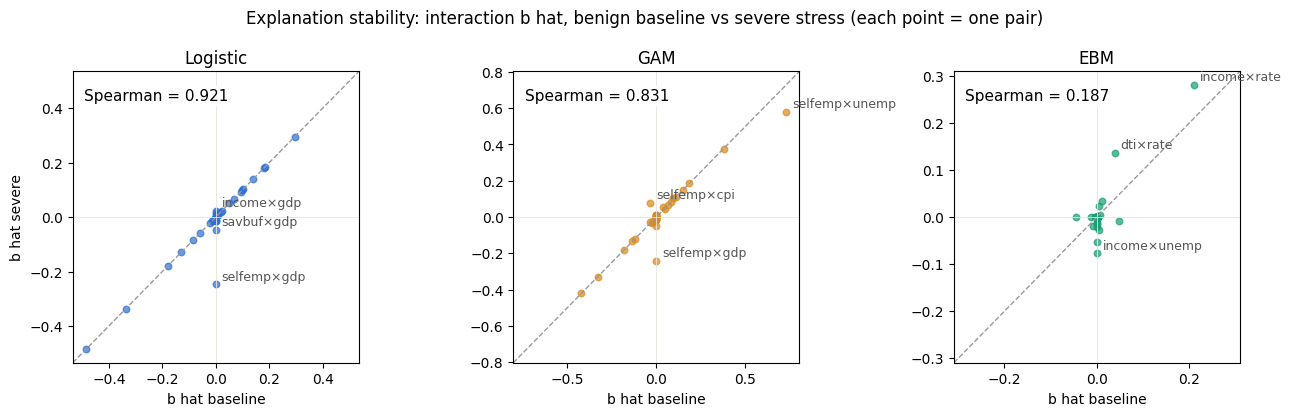

In [49]:
# Draw the fingerprint shift live: baseline b hat (x) versus severe b hat (y) for every pair, per model.
# Each panel is annotated with the rank correlation already computed and saved for this regime (the
# same number reported in the table above), and labels the three pairs whose b hat moved the most, so
# the numbers behind the table are visible on the plot itself, not just in a separate cell.
import matplotlib.pyplot as plt
es = load_json(f'{OUT}/explanation_stability.json')
CLR = {'Logistic': '#2a6fdb', 'GAM': '#d98a1e', 'EBM': '#1a9e74'}
pair_names = [p.replace('ix_', '').replace('_', '×') for p in es['pairs']]
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for k, m in enumerate(['Logistic', 'GAM', 'EBM']):
    xb = np.array(es['bhat'][m]['baseline']); ys = np.array(es['bhat'][m]['severe'])
    lim = max(0.05, float(np.abs(np.concatenate([xb, ys])).max()) * 1.1)
    ax[k].plot([-lim, lim], [-lim, lim], '--', color='#999', lw=1)
    ax[k].axhline(0, color='#e6e4dc', lw=0.6); ax[k].axvline(0, color='#e6e4dc', lw=0.6)
    ax[k].scatter(xb, ys, color=CLR[m], alpha=0.7, s=22)
    # Label the three pairs whose b hat moved the most between baseline and severe.
    disp = np.abs(ys - xb); top3 = np.argsort(disp)[-3:][::-1]
    for idx in top3:
        ax[k].annotate(pair_names[idx], (xb[idx], ys[idx]), fontsize=9, color='#555',
                       textcoords='offset points', xytext=(4, 3))
    # The rank correlation already saved for this regime, identical to the value shown in the table above.
    rc = es['stability'][m]['severe']['rank_corr_spearman']
    ax[k].text(0.04, 0.94, f'Spearman = {rc:.3f}', transform=ax[k].transAxes, fontsize=11,
              va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
    ax[k].set_xlim(-lim, lim); ax[k].set_ylim(-lim, lim); ax[k].set_title(m); ax[k].set_xlabel('b hat baseline')
ax[0].set_ylabel('b hat severe')
fig.suptitle('Explanation stability: interaction b hat, benign baseline vs severe stress (each point = one pair)')
fig.tight_layout(); plt.show()

### 4.5 Explanation faithfulness under stress (against a stressed structural oracle)

Section 4.4 measured whether each model's interaction explanation stays the *same* under stress. This section measures whether it stays *correct*. Because the emergent structural oracle is a deterministic function of the features, it can be evaluated on the stressed backgrounds themselves, giving the true interaction structure under COVID-19, the 2022 inflation window, and the severe forward path. Each frozen model's fingerprint is compared to that stressed oracle fingerprint on the same background, so this is a direct test of stressed explanation faithfulness, the severe-scenario structural reference whose absence the earlier critical evaluation identified as a gap. Stability and faithfulness are distinct: a model can keep telling the same story while that story drifts away from the truth, or move its story and still track the truth.

sign_agree_vs_oracle  rank_corr_vs_oracle  \
model    regime                                                      
EBM      COVID_2020                     0.367               -0.007   
         baseline                       1.000                0.594   
         inflation_2022                 0.900                0.399   
         severe                         1.000                0.556   
GAM      COVID_2020                     1.000                0.122   
         baseline                       1.000               -0.041   
         inflation_2022                 1.000                0.248   
         severe                         1.000                0.271   
Logistic COVID_2020                     0.683                0.039   
         baseline                       1.000                0.052   
         inflation_2022                 1.000                0.248   
         severe                         1.000                0.229   

                         rmse_vs_oracle  
model    regime                          
EBM      COVID_2020              0.1153  
         baseline                0.0347  
         inflation_2022          0.0495  
         severe                  0.0610  
GAM      COVID_2020              0.1801  
         baseline                0.1768  
         inflation_2022          0.1971  
         severe                  0.1503  
Logistic COVID_2020              0.1497  
         baseline                0.1302  
         inflation_2022          0.1484  
         severe                  0.1092

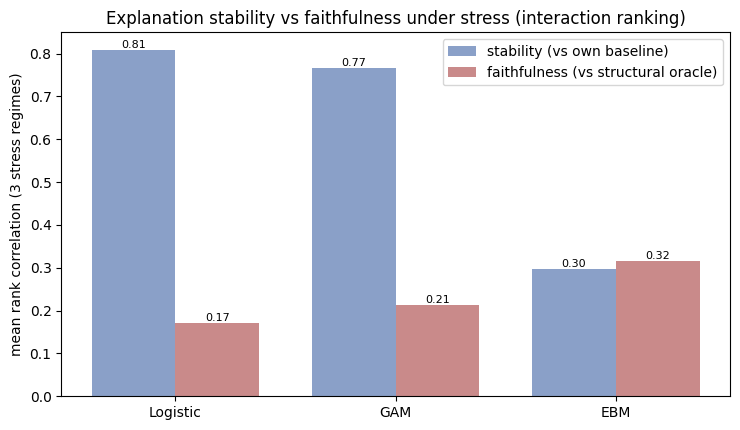

In [45]:
# Explanation FAITHFULNESS under stress: how close each model's interaction fingerprint is to the
# EMERGENT STRUCTURAL ORACLE evaluated on the SAME stressed background, per regime, averaged over the 5
# CRN seeds. Stability (the table above) asks whether a model tells the SAME story under stress as at
# baseline; faithfulness asks whether that story is CORRECT against the true stressed interaction
# structure. They are different questions, and a model can be stable yet wrong, or correct yet unstable.
es = load_json(f'{OUT}/explanation_stability.json')
faith = es.get('faithfulness', {})
if faith:
    rows = []
    for m, regs in faith.items():
        for rg, d in regs.items():
            rows.append({'model': m, 'regime': rg, 'sign_agree_vs_oracle': d['sign_agree'],
                         'rank_corr_vs_oracle': d['rank_corr_spearman'], 'rmse_vs_oracle': d['rmse']})
    display(pd.DataFrame(rows).set_index(['model', 'regime']).sort_index())

    # Compare, per model, stability (vs own baseline) against faithfulness (vs oracle), averaged over the
    # three stress regimes, so "stable" and "correct" can be read side by side.
    import matplotlib.pyplot as plt
    STRESS = ['severe', 'COVID_2020', 'inflation_2022']
    models = list(faith.keys()); CLR = {'Logistic': '#2a6fdb', 'GAM': '#d98a1e', 'EBM': '#1a9e74'}
    def _mean(dct, m, key):
        vals = [dct[m][rg][key] for rg in STRESS if rg in dct.get(m, {})]
        return float(np.mean(vals)) if vals else float('nan')
    stab_rc = [_mean(es['stability'], m, 'rank_corr_spearman') for m in models]
    faith_rc = [_mean(faith, m, 'rank_corr_spearman') for m in models]
    x = np.arange(len(models)); w = 0.38
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    ax.bar(x - w/2, stab_rc, w, color='#8aa0c8', label='stability (vs own baseline)')
    ax.bar(x + w/2, faith_rc, w, color='#c98a8a', label='faithfulness (vs structural oracle)')
    for xi, (s, f) in enumerate(zip(stab_rc, faith_rc)):
        ax.text(xi - w/2, s, f'{s:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi + w/2, f, f'{f:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylabel('mean rank correlation (3 stress regimes)')
    ax.axhline(0, color='#ccc', lw=0.7); ax.legend()
    ax.set_title('Explanation stability vs faithfulness under stress (interaction ranking)')
    fig.tight_layout(); plt.show()
else:
    print('No faithfulness block found (older explanation_stability.json). Re-run Stage 4 with REGENERATE=True to compute it.')